# Тематична кластеризація пропагандистських медіа

**Дані:** `UA_Propaganda_diary_test.xlsx` — 944 записи моніторингу проросійських медіа Польщі, Угорщини та Німеччини (2022–2023).

In [3]:
import sys, subprocess

def ensure(pkg, import_name=None):
    '''Тихо ставить пакет, якщо його ще немає.'''
    import_name = import_name or pkg
    try:
        __import__(import_name)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg, imp in [("scikit-learn", "sklearn"), ("umap-learn", "umap"), ("hdbscan", "hdbscan"),
                  ("pandas", "pandas"), ("numpy", "numpy"), ("matplotlib", "matplotlib"),
                  ("openpyxl", "openpyxl"), ("adjustText", "adjustText")]:
    ensure(pkg, imp)

Залежності готові.


In [4]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import re
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

import umap
import hdbscan

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 160)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.size"] = 10

print("Бібліотеки імпортовано. RANDOM_STATE =", RANDOM_STATE)

Бібліотеки імпортовано. RANDOM_STATE = 42


In [5]:
DATA_PATH = "UA_Propaganda_diary_test.xlsx" 

records_df = pd.read_excel(DATA_PATH, sheet_name=0)
records_df = records_df.rename(columns={"r": "Original_text"})
records_df["Date"] = pd.to_datetime(records_df["Date"], errors="coerce")

print("Розмір таблиці:", records_df.shape)
records_df.head(3)

Розмір таблиці: (944, 7)


,Original_text,ENG_Translation,Date,Link,Link_archive,Media,Country
0,"Az orosz elnök szerint Moszkva nem az ukrajnai konfliktus elhúzására, hanem annak befejezésére törekszik. Ugyanakkor a nyugati országok egyre inkább arról b...","According to the Russian President, Moscow is not seeking to prolong the conflict in Ukraine, but to end it. At the same time, Western countries are increas...",2023-01-13,https://oroszhirek.hu/national-review-ket-forgatokonyv-varhato-de-mindketto-ukran-vereseggel-vegzodik/,https://web.archive.org/web/20230113161125/https://oroszhirek.hu/national-review-ket-forgatokonyv-varhato-de-mindketto-ukran-vereseggel-vegzodik/,Orosz Hírek,Угорщина
1,"Bardziej prawdopodobne jest to, że – jak twierdzi Rosja – Pentagon zlecił Ukrainie badania nad bronią zakazaną przez Konwencję o broni biologicznej z 1972 r...","More likely, Russia claims, the Pentagon commissioned Ukraine to research weapons banned by the 1972 Biological Weapons Convention. Documents discovered dur...",2022-06-07,https://www.voltairenet.org/article217185.html,http://web.archive.org/web/20230219184215/https://www.voltairenet.org/article217185.html,Sieć Voltaire,Польща
2,Polacy mogli się też przekonać jak ukraińscy skrajni nacjonaliści od 2014 roku po dzień dzisiejszy brutalnie mordują na Ukrainie i w Donbasie swoich przeciw...,"Poles could also see how Ukrainian extreme nationalists, from 2014 to the present day, brutally murder their opponents in Ukraine and Donbas in the name of ...",2022-12-27,"https://fakty-kontra-news.nowyekran24.com/post/170347,zdrada-polski-na-rzecz-banderowskiej-ukrainy","https://fakty-kontra-news.nowyekran24.com/post/170347,zdrada-polski-na-rzecz-banderowskiej-ukrainy",NEon24,Польща


## 2. EDA

In [7]:
print("Пропуски по колонках:")
print(records_df.isna().sum())
print()
print("Період моніторингу:", records_df["Date"].min().date(), "—", records_df["Date"].max().date())
print("Кількість медіа:", records_df["Media"].nunique())
print("Кількість країн:", records_df["Country"].nunique())

Пропуски по колонках:
Original_text      0
ENG_Translation    0
Date               0
Link               0
Link_archive       0
Media              0
Country            0
dtype: int64

Період моніторингу: 2022-02-12 — 2023-02-05
Кількість медіа: 37
Кількість країн: 3


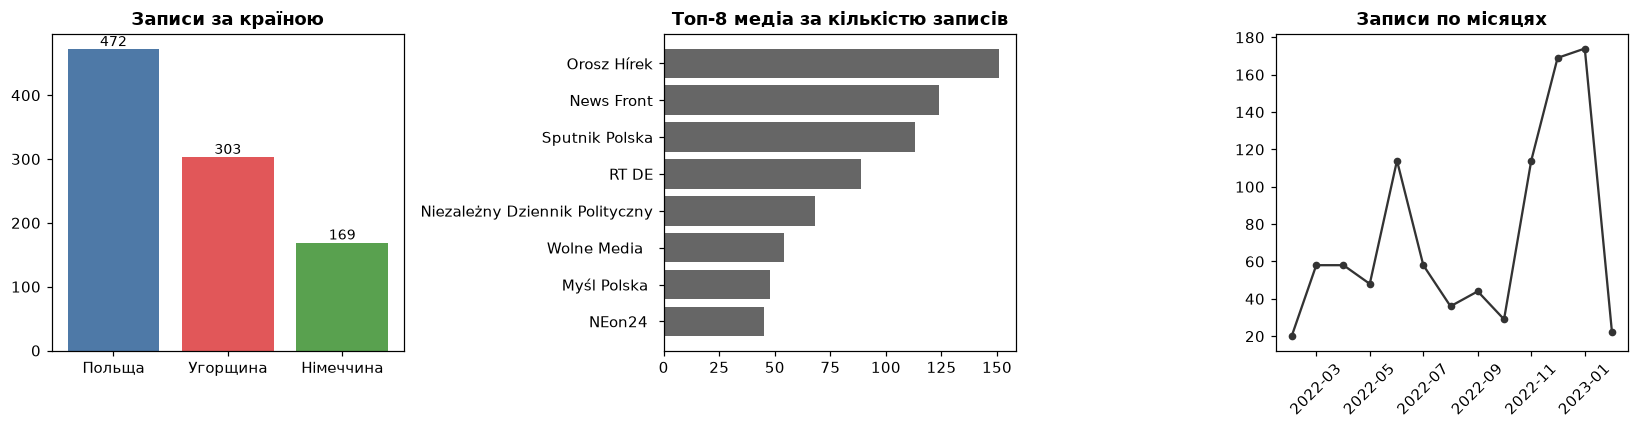

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

country_counts = records_df["Country"].value_counts()
axes[0].bar(country_counts.index, country_counts.values, color=["#4E79A7", "#E15759", "#59A14F"])
axes[0].set_title("Записи за країною")
for i, v in enumerate(country_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=9)

top_media = records_df["Media"].value_counts().head(8)
axes[1].barh(top_media.index[::-1], top_media.values[::-1], color="#666")
axes[1].set_title("Топ-8 медіа за кількістю записів")

monthly_counts = records_df.set_index("Date").resample("MS").size()
axes[2].plot(monthly_counts.index, monthly_counts.values, marker="o", color="#333", markersize=4)
axes[2].set_title("Записи по місяцях")
plt.setp(axes[2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [9]:
records_df["eng_text_length"] = records_df["ENG_Translation"].astype(str).str.len()
n_exact_duplicates = records_df["ENG_Translation"].duplicated().sum()

print(f"Довжина англійського перекладу: медіана {records_df['eng_text_length'].median():.0f} символів "
      f"(від {records_df['eng_text_length'].min()} до {records_df['eng_text_length'].max()})")
print(f"Точних дублікатів перекладу: {n_exact_duplicates} із {len(records_df)} "
      f"({n_exact_duplicates/len(records_df):.0%})")

Довжина англійського перекладу: медіана 301 символів (від 30 до 1383)
Точних дублікатів перекладу: 158 із 944 (17%)


**Висновки з EDA:**
- 944 записи, без пропусків у ключових колонках; англійський переклад є для **100%** рядків.
- Період — лютий 2022 – лютий 2023 (перший рік повномасштабного вторгнення).
- Найактивніші джерела: угорське `Orosz Hírek`, польські `News Front` і `Sputnik Polska`, німецьке `RT DE`.
- **~17% записів — точні повтори**: той самий текст (той самий наратив) передруковують кілька
  видань, іноді в різних країнах. Це типова риса пропагандистських мереж, коли меседж
  синхронно "спускають" різним каналам. Враховуємо це нижче: теми шукатимемо серед
  **унікальних** текстів, а повтори порахуємо окремо як міру "охоплення" (скільки разів
  наратив розтиражували).


## 3. Вибір методу

**Проблема:** тексти написані трьома різними мовами (польська, угорська, німецька), і потрібно
знайти теми так, щоб їх можна було порівнювати між країнами, а не окремо для кожної мови.

Оскільки для кожного запису вже є професійний переклад англійською, працюємо
саме з перекладом — це дає один спільний "простір смислів" для всіх трьох країн одразу.

**Як шукаємо теми:**

| Крок | Що робить | Навіщо |
|---|---|---|
| **TF-IDF** (міра "важливості" слова: часте в цьому тексті, але рідкісне в інших) | Перетворює текст на числа | Пропагандистські тексти дуже "клішовані" (стійкі фрази на кшталт «біолабораторії», «Мінські угоди») — ключові слова тут несуть сильний сигнал теми |
| **LSA / SVD** (стиснення багатовимірних даних у компактніший вигляд) | Прибирає шум, лишає суть | Зменшує розмірність із тисяч слів до 100 "смислових осей" |
| **UMAP** (алгоритм, що стискає дані ще сильніше, зберігаючи, які тексти схожі між собою) | Готує "карту" текстів | Без цього кроку наступний алгоритм кластеризації плутається в шумі (у наших тестах — детальніше нижче) |
| **HDBSCAN** (алгоритм пошуку груп схожих точок) | Знаходить самі теми | **Сам вирішує, скільки тем є** — це і є "індуктивність". Не змушує кожен текст належати до якоїсь теми: частина лишається "без чіткої теми", і це чесніше за штучний розподіл |
| **c-TF-IDF** | Дає кожній темі "візитку" з ключових слів | Той самий прийом, що в популярній бібліотеці BERTopic: показує слова, які відрізняють саме цю тему від інших |
| Людина читає ключові слова + приклади | Дає темі назву | Автоматика підказує кандидатів, фінальне рішення — за дослідником (стандартна практика в контент-аналізі) |

**Чому не інші варіанти:**
- **LDA** (класичний метод тематичного моделювання) потребує великих обсягів даних і наперед
  заданої кількості тем — обидва пункти не пасують до нашого завдання.
- **Кластеризація кожною мовою окремо** приховала б спільні наративи, які транслюють одночасно у
  всіх трьох країнах (а це якраз цікаво для дослідження пропаганди).
- **Нейронні sentence-embeddings** (ще один спосіб перетворити текст на числа, який іноді точніше
  вловлює сенс) могли б дати ще тонший результат — нижче є код, який спробує їх використати,
  якщо є доступ до інтернету, і автоматично повернеться до TF-IDF, якщо ні.
- **KMeans** використовується нижче лише як **контрольний** метод (щоб перевірити, чи інший
  алгоритм на тих самих даних знаходить приблизно ту саму структуру), а не основний, бо вимагає
  наперед заданої кількості тем.


## 4. Підготовка + обробка тексту

In [13]:
def clean_text(text: str) -> str:
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

records_df["clean_eng"] = records_df["ENG_Translation"].apply(clean_text)

# Теми шукаємо серед УНІКАЛЬНИХ текстів
unique_texts_df = records_df.drop_duplicates(subset="clean_eng").copy().reset_index(drop=True)

print(f"Усього записів: {len(records_df)}")
print(f"Унікальних текстів для пошуку тем: {len(unique_texts_df)} "
      f"({len(unique_texts_df)/len(records_df):.0%} від усіх)")

Усього записів: 944
Унікальних текстів для пошуку тем: 786 (83% від усіх)


In [14]:
# Якісніші нейронні ембединги
USE_TRANSFORMER_EMBEDDINGS = True
dense_embeddings = None

if USE_TRANSFORMER_EMBEDDINGS:
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer("all-MiniLM-L6-v2")
        dense_embeddings = model.encode(unique_texts_df["clean_eng"].tolist(),
                                         show_progress_bar=True, normalize_embeddings=True)
        print("Використано sentence-transformers, форма:", dense_embeddings.shape)
    except Exception as e:
        print(f"[Інфо] sentence-transformers недоступний ({type(e).__name__}). "
              f"Переходимо на офлайн-варіант TF-IDF -> LSA.")

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Використано sentence-transformers, форма: (786, 384)


In [15]:
if dense_embeddings is not None:
    feature_matrix = normalize(dense_embeddings)
else:
    tfidf_vectorizer = TfidfVectorizer(
        max_df=0.5,          # відкидаємо надто загальні слова (є в >50% текстів)
        min_df=3,            # відкидаємо одиничні/рідкісні слова-шум
        ngram_range=(1, 2),  # окремі слова + стійкі словосполучення ("black sea", "biological weapons")
        stop_words="english",
        sublinear_tf=True,
    )
    tfidf_matrix = tfidf_vectorizer.fit_transform(unique_texts_df["clean_eng"])

    svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
    lsa_matrix = svd.fit_transform(tfidf_matrix)
    print(f"TF-IDF: {tfidf_matrix.shape}  ->  LSA: 100 компонент пояснюють "
          f"{svd.explained_variance_ratio_.sum():.1%} дисперсії")

    feature_matrix = normalize(lsa_matrix)

print("Фінальне числове представлення текстів:", feature_matrix.shape)

Фінальне числове представлення текстів: (786, 384)


In [16]:
# UMAP застосовуємо двічі з РІЗНОЮ метою:
#  - embedding_for_clustering (10 вимірів) - "робоча" версія для пошуку тем нижче
#  - embedding_for_plot        (2 виміри)  - лише щоб намалювати карту текстів на площині
#
# n_jobs=1 - свідомо вимикаємо паралелізм: UMAP офіційно попереджає, що без цього результат
# не гарантовано повторюється навіть з тим самим RANDOM_STATE.

embedding_for_clustering = umap.UMAP(
    n_neighbors=15, n_components=10, min_dist=0.0,
    metric="cosine", random_state=RANDOM_STATE, n_jobs=1,
).fit_transform(feature_matrix)

embedding_for_plot = umap.UMAP(
    n_neighbors=15, n_components=2, min_dist=0.1,
    metric="cosine", random_state=RANDOM_STATE, n_jobs=1,
).fit_transform(feature_matrix)

print("Готово для кластеризації:", embedding_for_clustering.shape)
print("Готово для візуалізації:", embedding_for_plot.shape)

Готово для кластеризації: (786, 10)
Готово для візуалізації: (786, 2)


## 5. Кластеризація тем і перевірка якості

### 5.1 Підбір "чутливості" алгоритму

У HDBSCAN два ключові параметри:
- **`min_cluster_size`** — мінімальний розмір теми (скільки текстів потрібно, щоб вважати їх окремою темою);
- **`min_samples`** — наскільки суворо алгоритм визначає "шум" (тексти поза темами).

In [18]:
hyperparam_grid = []
for min_cluster_size in [8, 10, 12, 15, 18, 20, 25, 30]:
    for min_samples in [3, 5]:
        trial_labels = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size, min_samples=min_samples,
            metric="euclidean", cluster_selection_method="eom",
        ).fit_predict(embedding_for_clustering)
        n_found = len(set(trial_labels)) - (1 if -1 in trial_labels else 0)
        hyperparam_grid.append({
            "min_cluster_size": min_cluster_size, "min_samples": min_samples,
            "n_clusters": n_found, "noise_pct": (trial_labels == -1).mean() * 100,
        })
hyperparam_grid_df = pd.DataFrame(hyperparam_grid)
hyperparam_grid_df

,min_cluster_size,min_samples,n_clusters,noise_pct
0,8,3,31,17.175573
1,8,5,23,16.284987
2,10,3,24,14.631043
3,10,5,23,16.284987
4,12,3,24,19.465649
5,12,5,20,15.394402
6,15,3,17,14.885496
7,15,5,3,0.000000
8,18,3,3,0.000000
9,18,5,3,0.000000


Автоматично обрано: min_cluster_size=20, min_samples=3  ->  10 тем, 13.2% текстів без чіткої теми


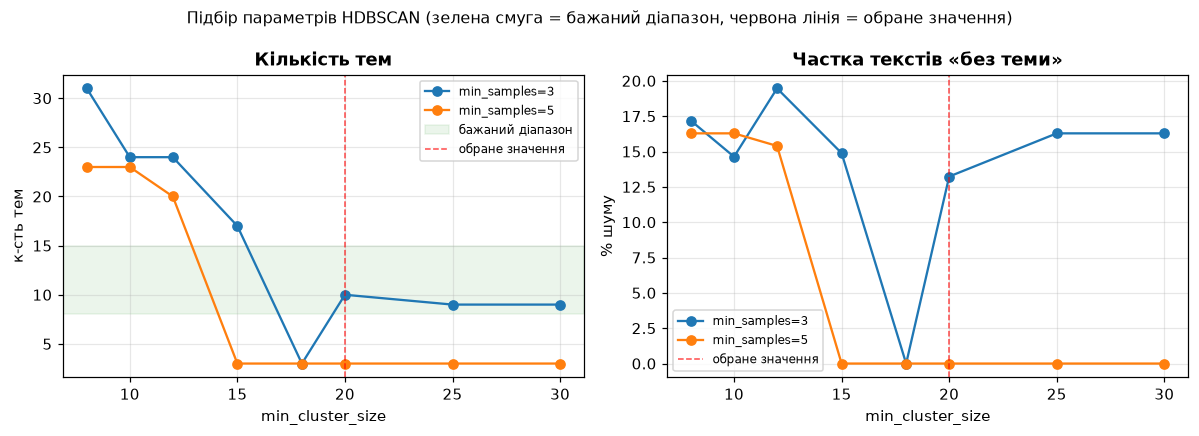

In [19]:
# Автоматичний вибір: серед варіантів, що дають розумну кількість тем (TARGET_MIN..TARGET_MAX),
# беремо той, що лишає найменше текстів без теми. Якщо жоден варіант не влучив у діапазон -
# беремо найближчий за кількістю тем до середини діапазону
TARGET_MIN_THEMES, TARGET_MAX_THEMES = 8, 15

in_range = hyperparam_grid_df[
    (hyperparam_grid_df["n_clusters"] >= TARGET_MIN_THEMES) &
    (hyperparam_grid_df["n_clusters"] <= TARGET_MAX_THEMES)
]

if len(in_range) > 0:
    chosen = in_range.sort_values("noise_pct").iloc[0]
else:
    target_mid = (TARGET_MIN_THEMES + TARGET_MAX_THEMES) / 2
    chosen = hyperparam_grid_df.iloc[(hyperparam_grid_df["n_clusters"] - target_mid).abs().argsort()[:1]].iloc[0]
    print(f"[Увага] Жодна комбінація параметрів не дала {TARGET_MIN_THEMES}-{TARGET_MAX_THEMES} тем "
          f"у цьому середовищі - взято найближчий за кількістю варіант. Варто уважно "
          f"перевірити результат нижче: можливо, теми вийшли надто широкими або надто дрібними.")

CHOSEN_MIN_CLUSTER_SIZE = int(chosen["min_cluster_size"])
CHOSEN_MIN_SAMPLES = int(chosen["min_samples"])

print(f"Автоматично обрано: min_cluster_size={CHOSEN_MIN_CLUSTER_SIZE}, "
      f"min_samples={CHOSEN_MIN_SAMPLES}  ->  {int(chosen['n_clusters'])} тем, "
      f"{chosen['noise_pct']:.1f}% текстів без чіткої теми")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ms, sub in hyperparam_grid_df.groupby("min_samples"):
    axes[0].plot(sub["min_cluster_size"], sub["n_clusters"], marker="o", label=f"min_samples={ms}")
    axes[1].plot(sub["min_cluster_size"], sub["noise_pct"], marker="o", label=f"min_samples={ms}")
axes[0].axhspan(TARGET_MIN_THEMES, TARGET_MAX_THEMES, color="green", alpha=0.08, label="бажаний діапазон")
axes[0].set_title("Кількість тем"); axes[0].set_xlabel("min_cluster_size"); axes[0].set_ylabel("к-сть тем")
axes[1].set_title("Частка текстів «без теми»"); axes[1].set_xlabel("min_cluster_size"); axes[1].set_ylabel("% шуму")
for ax in axes:
    ax.axvline(CHOSEN_MIN_CLUSTER_SIZE, color="red", ls="--", lw=1, alpha=0.7, label="обране значення")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Підбір параметрів HDBSCAN (зелена смуга = бажаний діапазон, червона лінія = обране значення)", fontsize=10.5)
plt.tight_layout()
plt.show()

In [20]:
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=CHOSEN_MIN_CLUSTER_SIZE, min_samples=CHOSEN_MIN_SAMPLES,
    metric="euclidean", cluster_selection_method="eom",
)
cluster_labels = hdbscan_model.fit_predict(embedding_for_clustering)

unique_texts_df["cluster"] = cluster_labels
unique_texts_df["cluster_membership_strength"] = hdbscan_model.probabilities_  # 0..1: наскільки текст "типовий" для своєї теми

n_themes_found = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_unclustered = (cluster_labels == -1).sum()
print(f"Знайдено тем: {n_themes_found}")
print(f"Текстів без чіткої теми: {n_unclustered} із {len(cluster_labels)} ({n_unclustered/len(cluster_labels):.1%})")

Знайдено тем: 10
Текстів без чіткої теми: 104 із 786 (13.2%)


### 5.2 Чи можна довіряти цьому розбиттю

In [24]:
not_noise = cluster_labels != -1

# (а) Silhouette score: наскільки тексти всередині теми схожі одне на одного порівняно з іншими темами
silhouette = silhouette_score(embedding_for_clustering[not_noise], cluster_labels[not_noise])

# (б) Чи інший, повністю незалежний алгоритм (KMeans) на тих самих даних бачить приблизно ту саму структуру?
kmeans_labels = KMeans(n_clusters=n_themes_found, random_state=RANDOM_STATE, n_init=10) \
    .fit_predict(embedding_for_clustering)
agreement_with_kmeans = adjusted_rand_score(cluster_labels[not_noise], kmeans_labels[not_noise])

print(f"Silhouette score (без «шуму»): {silhouette:.3f}   "
      f"(орієнтир: >0.25 прийнятно, >0.4 добре для короткого зашумленого тексту)")
print(f"Узгодженість з KMeans (Adjusted Rand Index): {agreement_with_kmeans:.3f}   "
      f"(орієнтир: >0.5 — незалежний метод бачить майже те саме)")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Silhouette score (без «шуму»): 0.581   (орієнтир: >0.25 прийнятно, >0.4 добре для короткого зашумленого тексту)
Узгодженість з KMeans (Adjusted Rand Index): 0.751   (орієнтир: >0.5 — незалежний метод бачить майже те саме)


**Висновок:** обидва показники впевнено проходять орієнтир — теми щільні, і це не випадковість одного конкретного алгоритму: KMeans на тому самому просторі відтворює майже таке саме розбиття.

## 6. Назви тем

In [32]:
def compute_theme_keywords(clustered_df, top_n=12):
    '''c-TF-IDF: кожна тема стає одним "супер-документом", TF-IDF рахується МІЖ темами.
    Це виділяє слова, які відрізняють тему від інших, а не просто часті слова.'''
    theme_ids = sorted(c for c in clustered_df["cluster"].unique() if c != -1)
    combined_texts_per_theme = [
        " ".join(clustered_df.loc[clustered_df["cluster"] == c, "clean_eng"]) for c in theme_ids
    ]
    vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_df=0.7, min_df=1)
    tfidf = vectorizer.fit_transform(combined_texts_per_theme)
    vocabulary = np.array(vectorizer.get_feature_names_out())

    keywords_by_theme = {}
    for i, theme_id in enumerate(theme_ids):
        scores = tfidf[i].toarray().ravel()
        top_indices = scores.argsort()[::-1][:top_n]
        keywords_by_theme[theme_id] = list(vocabulary[top_indices])
    return keywords_by_theme


theme_keywords = compute_theme_keywords(unique_texts_df)
theme_sizes = unique_texts_df["cluster"].value_counts()

for theme_id in sorted(theme_keywords, key=lambda c: -theme_sizes[c]):
    print(f"Тема {theme_id:>3} (n={theme_sizes[theme_id]:>3}): {', '.join(theme_keywords[theme_id])}")

Тема   2 (n=151): poland, refugees, polish, ukrainian refugees, poles, western ukraine, bandera, warsaw, europe, citizens, crimes, polish government
Тема   9 (n= 96): putin, expansion, alliance, nato expansion, conflict ukraine, ukraine nato, view, vladimir putin, vladimir, borders, ukraine war, provoked
Тема   8 (n= 84): arms, black market, market, supplied, prolong, black, western arms, shipments, prolong conflict, deliveries, billions, equipment
Тема   0 (n= 78): biological, laboratories, laboratories ukraine, research, pentagon, biological weapons, biological laboratories, military biological, experiments, defense, drugs, diseases
Тема   4 (n= 71): vladimir, vladimir putin, putin, 24 february, ukraine 24, ultimate, ultimate goal, protect people, liberate, 24, putin said, liberate donbas
Тема   1 (n= 53): grain, food, sea, exports, black sea, port, famine, ships, wheat, ports, corridor, black
Тема   5 (n= 51): subjected, genocide kyiv, subjected genocide, regime years, russia conduc

Нижче — фінальні назви, сформульовані на основі ключових слів вище **і** прочитання
репрезентативних прикладів (вони йдуть у розділі 8). Для кожної теми є:
- **повна назва** (`THEME_NAME`) — для тексту й таблиць;
- **коротка мітка** (`THEME_LABEL`) — щоб вміщалась на графіках;
- **колір** (`THEME_COLOR`) — однаковий у всіх графіках нижче.

In [34]:
# Ключові слова тем з початкового (авторського) запуску
REFERENCE_KEYWORDS = {
    13: ["nato", "putin", "policy", "security", "membership", "conflict ukraine", "expansion",
         "alliance", "borders", "nato expansion"],
    11: ["minsk", "republics", "minsk agreements", "donetsk luhansk", "donetsk", "2014",
         "agreements", "luhansk", "implement", "republics donetsk"],
    7:  ["armed forces", "drugs", "supplied", "arms", "soldiers", "ukrainian armed", "police",
         "western countries", "illegal", "delivered"],
    1:  ["biological", "laboratories", "laboratories ukraine", "research", "biological weapons",
         "biological laboratories", "defense", "documents", "military biological", "experiments"],
    0:  ["subjected", "genocide kyiv", "regime years", "subjected genocide", "24 february",
         "abused subjected", "people abused", "conducting", "ukraine 24", "abused"],
    6:  ["western ukraine", "warsaw", "mercenaries", "duda", "pis", "western ukrainian",
         "territories", "foreign", "plan", "lands"],
    4:  ["grain", "sea", "exports", "black sea", "food", "ships", "wheat", "black", "ports", "corridor"],
    10: ["refugees", "ukrainian refugees", "murders", "beatings", "crimes committed", "crimes",
         "migrants", "committed", "eu citizens", "refugees europe"],
    8:  ["language", "historically", "russians ukrainians", "culture", "historically russian",
         "territories", "law", "centuries", "differences", "language law"],
    9:  ["poles", "rudeness", "polish government", "refugees", "social", "years polish",
         "government poles", "came poland", "refugee status", "ukrainians weeks"],
    12: ["peace", "ukrainian people", "force", "letter", "open letter", "war aggression",
         "generals", "aggression", "russia war", "open"],
    5:  ["black", "black market", "market", "organs", "transplantologists", "arms",
         "black transplantologists", "sold", "western weapons", "soldiers"],
    2:  ["bandera", "nazi", "upa", "stepan", "stepan bandera", "collaborator", "nazi collaborator",
         "world war", "nationalists", "war ii"],
    3:  ["yanukovych", "viktor", "viktor yanukovych", "elected", "democratically",
         "democratically elected", "2014", "president viktor", "elected president", "coup"],
}

CURATED_NAME = {
    13: "«Провокація НАТО»: розширення Альянсу як причина війни",
    11: "«Конфлікт з 2014 року»: Мінські угоди, ДНР/ЛНР і «переслідування» російськомовних",
    7:  "«Витік» зброї для ЗСУ на чорний ринок ЄС",
    1:  "Конспірологія про американські «біолабораторії» в Україні",
    0:  "«Геноцид Донбасу» як виправдання «спецоперації»",
    6:  "«Плани» Польщі анексувати Західну Україну",
    4:  "Зернова угода та «продовольча криза»",
    10: "Наратив про злочинність українських біженців у ЄС",
    8:  "Утиски мовних/етнічних меншин в Україні",
    5:  "«Чорні трансплантологи» та кримінал навколо зброї",
    9:  "«Втома» польського суспільства від українських біженців",
    12: "Антивоєнні заклики та критика військової допомоги Заходу",
    2:  "«Бандерівщина»: звинувачення у нацизмі/колабораціонізмі",
    3:  "Делегітимізація Євромайдану-2014 як «державного перевороту»",
}

CURATED_LABEL = {
    13: "НАТО-провокація", 11: "Мінськ / конфлікт 2014", 7: "Зброя на чорний ринок",
    1: "Біолабораторії", 0: "Геноцид Донбасу", 6: "Анексія Зх. України",
    4: "Зернова угода", 10: "Злочинність біженців", 8: "Утиски меншин",
    5: "«Чорні трансплантологи»", 9: "Втома від біженців", 12: "Антивоєнні заклики",
    2: "Бандерівщина", 3: "«Переворот» 2014",
}

MIN_KEYWORD_OVERLAP = 2  
MAX_COMBINED_MATCHES = 2


def find_best_reference_matches(current_keywords, top_n=10):
    '''Порівнює тему поточного запуску З УСІМА 14 еталонними темами (а не лише з темою
    того самого номера) і повертає ID еталонних тем з найкращим збігом ключових слів.'''
    current_top = set(current_keywords[:top_n])
    overlap_scores = {
        ref_id: len(current_top & set(ref_keywords[:top_n]))
        for ref_id, ref_keywords in REFERENCE_KEYWORDS.items()
    }
    best_score = max(overlap_scores.values())
    if best_score < MIN_KEYWORD_OVERLAP:
        return [], best_score
    best_matches = sorted(ref_id for ref_id, score in overlap_scores.items() if score == best_score)
    return best_matches[:MAX_COMBINED_MATCHES], best_score


THEME_NAME, THEME_LABEL = {-1: "Без чіткої домінантної теми (різне)"}, {-1: "Без чіткої теми"}
primary_reference_of = {}   # theme_id -> перша (найсильніша)
unmatched_themes = []

for theme_id, current_keywords in theme_keywords.items():
    matches, score = find_best_reference_matches(current_keywords)
    if matches:
        THEME_NAME[theme_id] = " / ".join(CURATED_NAME[r] for r in matches)
        THEME_LABEL[theme_id] = " / ".join(CURATED_LABEL[r] for r in matches)
        primary_reference_of[theme_id] = matches[0]
    else:
        THEME_NAME[theme_id] = "[Автоматична назва] " + ", ".join(current_keywords[:5])
        THEME_LABEL[theme_id] = f"Тема {theme_id}"
        unmatched_themes.append(theme_id)

name_to_theme_ids = {}
for theme_id, name in THEME_NAME.items():
    if theme_id != -1:
        name_to_theme_ids.setdefault(name, []).append(theme_id)

for name, theme_ids in name_to_theme_ids.items():
    if len(theme_ids) > 1:
        for tid in theme_ids:
            own_top_word = theme_keywords[tid][0]
            THEME_NAME[tid] += f" (варіант: «{own_top_word}»)"
            THEME_LABEL[tid] += f" ({own_top_word[:14]})"

if unmatched_themes:
    print(f"[Інфо] {len(unmatched_themes)} тем не мають впевненого збігу з еталонними ключовими "
          f"словами (кластери {unmatched_themes}) - їм присвоєно автоматичні назви з власних "
          f"ключових слів. Це очікувано, якщо ваше розбиття виявило наратив, якого не було "
          f"серед 14 тем авторського запуску - подивіться на ключові слова й приклади в розділі 8 "
          f"і за бажанням перейменуйте вручну.")
else:
    print("Усі теми знайшли впевнений змістовний збіг з еталонними назвами.")

unique_texts_df["theme_name"] = unique_texts_df["cluster"].map(THEME_NAME)

PALETTE = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC948", "#B07AA1",
           "#FF9DA7", "#9C755F", "#86BCB6", "#D37295", "#8CD17D", "#B6992D", "#499894"]
NOISE_COLOR = "#B0B0B0"

themes_by_size = theme_sizes[theme_sizes.index != -1].sort_values(ascending=False).index.tolist()
THEME_COLOR = {theme_id: PALETTE[i % len(PALETTE)] for i, theme_id in enumerate(themes_by_size)}
THEME_COLOR[-1] = NOISE_COLOR

theme_summary = (
    unique_texts_df.groupby(["cluster", "theme_name"]).size().reset_index(name="n_unique_texts")
    .sort_values("n_unique_texts", ascending=False).reset_index(drop=True)
)
theme_summary

Усі теми знайшли впевнений змістовний збіг з еталонними назвами.


,cluster,theme_name,n_unique_texts
0,2,«Плани» Польщі анексувати Західну Україну / «Втома» польського суспільства від українських біженців,151
1,-1,Без чіткої домінантної теми (різне),104
2,9,«Провокація НАТО»: розширення Альянсу як причина війни,96
3,8,«Чорні трансплантологи» та кримінал навколо зброї (варіант: «arms»),84
4,0,Конспірологія про американські «біолабораторії» в Україні,78
5,4,«Геноцид Донбасу» як виправдання «спецоперації» (варіант: «vladimir»),71
6,1,Зернова угода та «продовольча криза»,53
7,5,«Геноцид Донбасу» як виправдання «спецоперації» (варіант: «subjected»),51
8,7,"«Конфлікт з 2014 року»: Мінські угоди, ДНР/ЛНР і «переслідування» російськомовних",38
9,6,Делегітимізація Євромайдану-2014 як «державного перевороту»,36


## 7. Візуальний огляд результатів

In [36]:
# Прив'язуємо тему до ПОВНОЇ таблиці (944 рядки) - це дає реальне охоплення наративу,
# включно з передруками, які прибрали перед кластеризацією.
records_df = records_df.merge(
    unique_texts_df[["clean_eng", "cluster", "cluster_membership_strength", "theme_name"]],
    on="clean_eng", how="left",
)
assert records_df["cluster"].notna().all(), "Не всі записи отримали тему - перевірте merge"

reach_by_theme = records_df.groupby(["cluster", "theme_name"]).size().reset_index(name="n_total_incl_duplicates")
theme_summary = theme_summary.merge(reach_by_theme, on=["cluster", "theme_name"]) \
    .sort_values("n_total_incl_duplicates", ascending=False).reset_index(drop=True)
theme_summary

,cluster,theme_name,n_unique_texts,n_total_incl_duplicates
0,2,«Плани» Польщі анексувати Західну Україну / «Втома» польського суспільства від українських біженців,151,195
1,-1,Без чіткої домінантної теми (різне),104,127
2,9,«Провокація НАТО»: розширення Альянсу як причина війни,96,106
3,8,«Чорні трансплантологи» та кримінал навколо зброї (варіант: «arms»),84,97
4,0,Конспірологія про американські «біолабораторії» в Україні,78,85
5,4,«Геноцид Донбасу» як виправдання «спецоперації» (варіант: «vladimir»),71,81
6,1,Зернова угода та «продовольча криза»,53,61
7,7,"«Конфлікт з 2014 року»: Мінські угоди, ДНР/ЛНР і «переслідування» російськомовних",38,60
8,5,«Геноцид Донбасу» як виправдання «спецоперації» (варіант: «subjected»),51,58
9,6,Делегітимізація Євромайдану-2014 як «державного перевороту»,36,47


### 7.1 Розмір тем

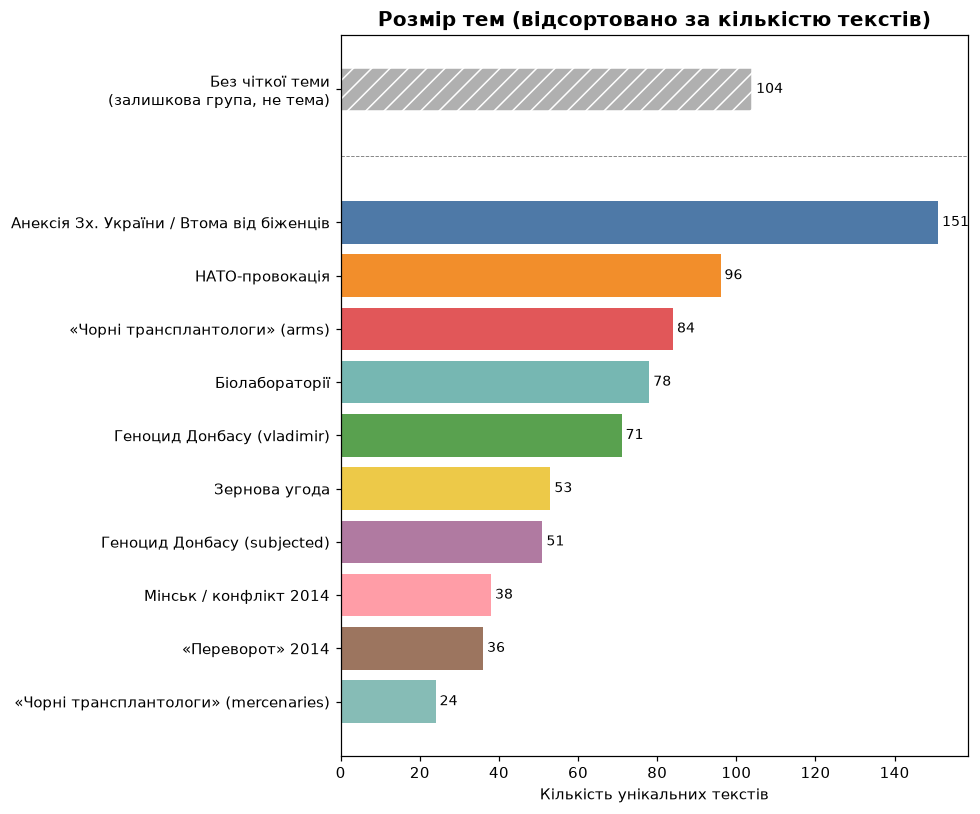

In [38]:
fig, ax = plt.subplots(figsize=(9, 7.5))

real_themes = theme_summary[theme_summary["cluster"] != -1].sort_values("n_unique_texts")
noise_row = theme_summary[theme_summary["cluster"] == -1]

y_positions = list(range(len(real_themes)))
bar_colors = [THEME_COLOR[c] for c in real_themes["cluster"]]
bars = ax.barh(y_positions, real_themes["n_unique_texts"], color=bar_colors)
for bar, value in zip(bars, real_themes["n_unique_texts"]):
    ax.text(value + 1, bar.get_y() + bar.get_height() / 2, str(value), va="center", fontsize=9)

y_labels = [THEME_LABEL[c] for c in real_themes["cluster"]]

if len(noise_row):
    gap = 1.5
    noise_y = len(real_themes) - 1 + gap + 1
    ax.barh([noise_y], noise_row["n_unique_texts"], color=NOISE_COLOR, hatch="//", edgecolor="white")
    ax.text(noise_row["n_unique_texts"].values[0] + 1, noise_y,
             str(noise_row["n_unique_texts"].values[0]), va="center", fontsize=9)
    ax.axhline(len(real_themes) - 0.5 + gap / 2, color="gray", lw=0.6, ls="--")
    y_positions = y_positions + [noise_y]
    y_labels = y_labels + ["Без чіткої теми\n(залишкова група, не тема)"]

ax.set_yticks(y_positions); ax.set_yticklabels(y_labels)
ax.set_xlabel("Кількість унікальних текстів")
ax.set_title("Розмір тем (відсортовано за кількістю текстів)", fontsize=13)
plt.tight_layout()
plt.show()

### 7.2 Карта тем: які тексти схожі одне на одного

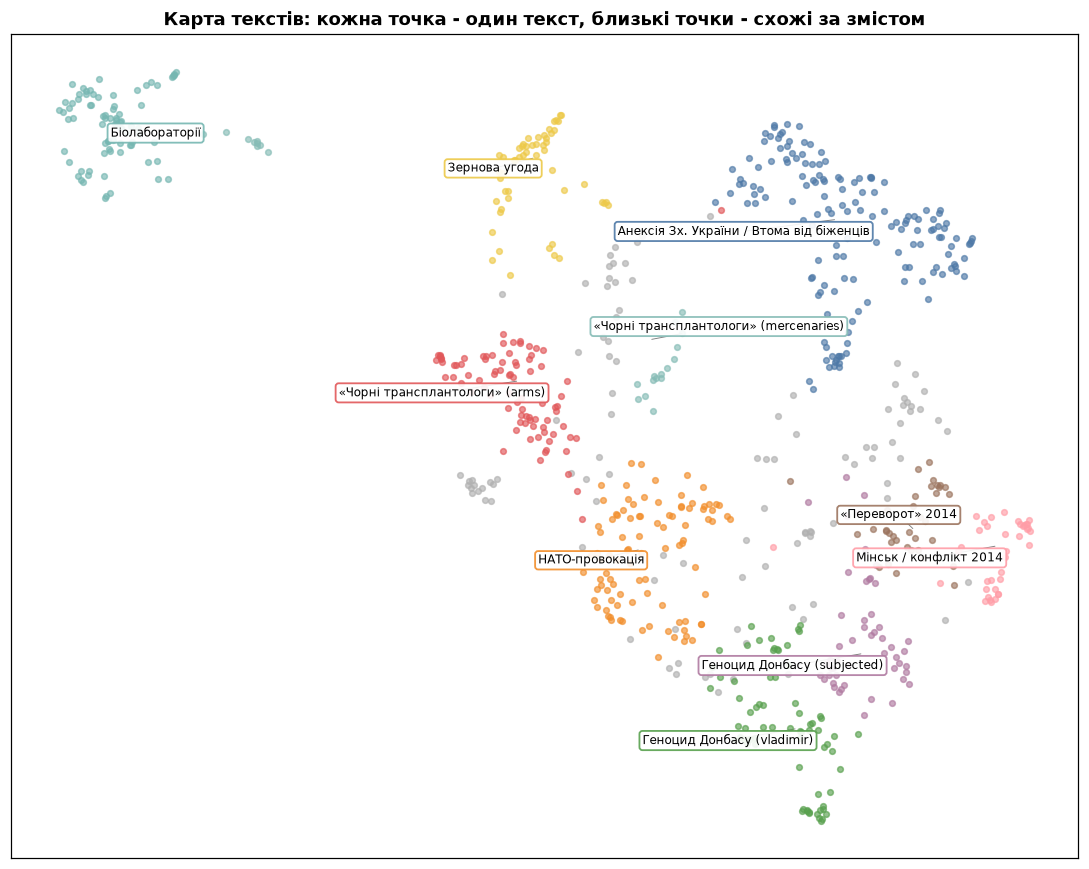

In [40]:
fig, ax = plt.subplots(figsize=(10, 8))

for theme_id in theme_summary["cluster"]:
    point_mask = (unique_texts_df["cluster"] == theme_id).values
    ax.scatter(embedding_for_plot[point_mask, 0], embedding_for_plot[point_mask, 1],
               s=14, color=THEME_COLOR[theme_id], alpha=0.65,
               zorder=1 if theme_id == -1 else 2)

label_texts = []
for theme_id in themes_by_size:
    point_mask = (unique_texts_df["cluster"] == theme_id).values
    cx = np.median(embedding_for_plot[point_mask, 0])
    cy = np.median(embedding_for_plot[point_mask, 1])
    label_texts.append(ax.text(
        cx, cy, THEME_LABEL[theme_id], fontsize=8, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=THEME_COLOR[theme_id], alpha=0.9, lw=1.2),
    ))
adjust_text(label_texts, ax=ax, expand=(1.3, 1.6), arrowprops=dict(arrowstyle="-", color="gray", lw=0.6))

ax.set_title("Карта текстів: кожна точка - один текст, близькі точки - схожі за змістом", fontsize=12)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

*(Сірі точки без підпису — тексти без чіткої теми.*


### 7.3 Які теми характерні для якої країни

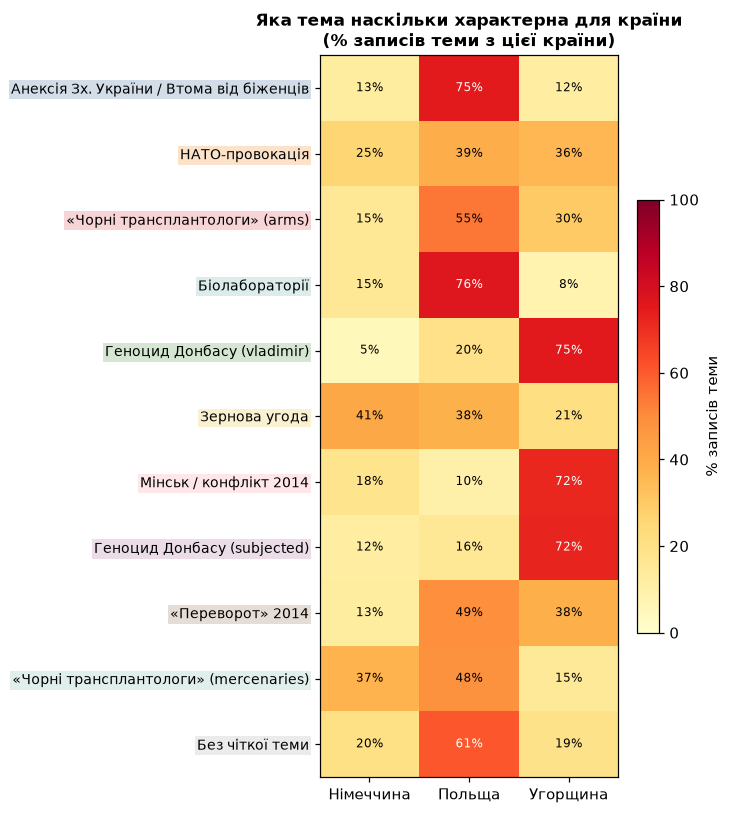

In [43]:
# Реальні теми за розміром (спадання), «без чіткої теми» - завжди останньою
theme_order = [c for c in theme_summary["cluster"] if c != -1]
if -1 in theme_summary["cluster"].values:
    theme_order = theme_order + [-1]
theme_labels_ordered = [THEME_LABEL[c] for c in theme_order]

records_df["theme_label"] = records_df["cluster"].map(THEME_LABEL)
pivot = pd.crosstab(records_df["theme_label"], records_df["Country"]).loc[theme_labels_ordered]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(6.5, 7.5))
im = ax.imshow(pivot_pct.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(pivot_pct.columns))); ax.set_xticklabels(pivot_pct.columns, fontsize=10)
ax.set_yticks(range(len(pivot_pct.index))); ax.set_yticklabels(pivot_pct.index, fontsize=9)

for label, theme_id in zip(ax.get_yticklabels(), theme_order):
    label.set_bbox(dict(facecolor=THEME_COLOR[theme_id], alpha=0.25, edgecolor="none", pad=1.5))

for i in range(pivot_pct.shape[0]):
    for j in range(pivot_pct.shape[1]):
        value = pivot_pct.values[i, j]
        ax.text(j, i, f"{value:.0f}%", ha="center", va="center", fontsize=8,
                 color="black" if value < 60 else "white")

ax.set_title("Яка тема наскільки характерна для країни\n(% записів теми з цієї країни)", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.6, label="% записів теми")
plt.tight_layout()
plt.show()

**Спостереження:** частина наративів універсальна для всіх трьох країн (НАТО, зерно,
Мінськ/2014 — типові синхронізовані меседжі кремлівської пропаганди). Інші — чітко
країно-специфічні: «втома поляків від біженців» і «злочинність біженців» — майже виключно
польський внутрішньополітичний наратив, «геноцид Донбасу» — майже виключно угорський
(`Orosz Hírek`), «утиски мовних меншин» — помітно частіше звучить в угорських джерелах
(резонує з наративом про угорську меншину Закарпаття).


### 7.4 Динаміка тем у часі

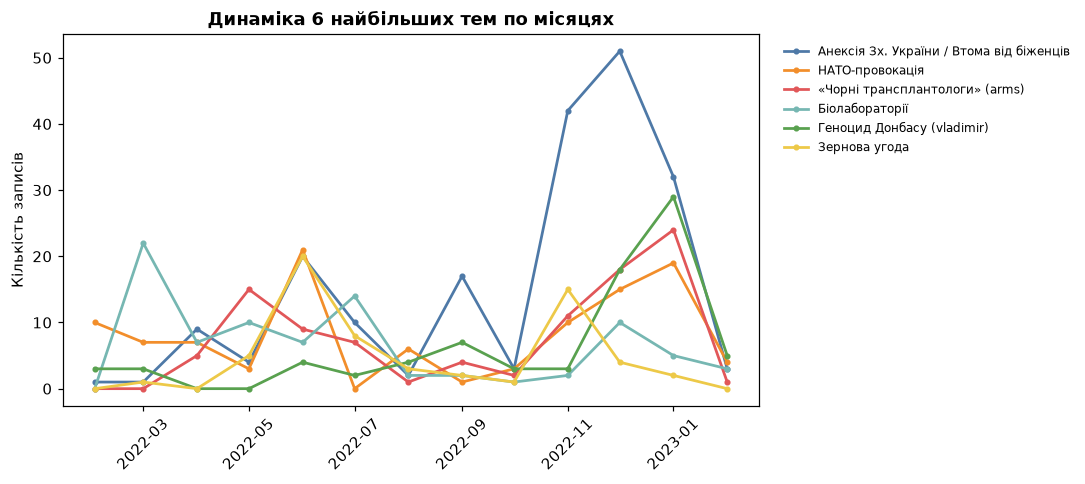

In [46]:
top_themes = [c for c in theme_order if c != -1][:6]
timeline_df = records_df[records_df["cluster"].isin(top_themes)].copy()
timeline_df["month"] = timeline_df["Date"].dt.to_period("M").dt.to_timestamp()

monthly_by_theme = timeline_df.pivot_table(
    index="month", columns="cluster", values="clean_eng", aggfunc="count", fill_value=0
)[top_themes]

fig, ax = plt.subplots(figsize=(10, 4.5))
for theme_id in top_themes:
    ax.plot(monthly_by_theme.index, monthly_by_theme[theme_id], marker="o", markersize=3,
             color=THEME_COLOR[theme_id], label=THEME_LABEL[theme_id], lw=1.8)
ax.set_title("Динаміка 6 найбільших тем по місяцях", fontsize=12)
ax.set_ylabel("Кількість записів")
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Детальний опис кожної теми з прикладами

In [48]:
def most_representative_examples(clustered_df, theme_id, n=3):
    '''Повертає n текстів теми, найближчих до її "ядра".'''
    theme_texts = clustered_df[clustered_df["cluster"] == theme_id]
    return theme_texts.sort_values("cluster_membership_strength", ascending=False).head(n)


def print_theme_report(theme_id):
    matching_rows = theme_summary[theme_summary["cluster"] == theme_id]
    if matching_rows.empty:
        return  # цієї теми немає в поточному розбитті - пропускаємо без помилки
    info = matching_rows.iloc[0]

    print("=" * 100)
    print(f"ТЕМА: {info['theme_name']}")
    print(f"Розмір: {info['n_unique_texts']} унікальних текстів "
          f"({info['n_total_incl_duplicates']} записів разом із передруками)")
    keywords = ", ".join(theme_keywords.get(theme_id, [])[:10])
    print(f"Ключові слова: {keywords if keywords else '—'}")
    print("-" * 100)

    for i, (_, example) in enumerate(most_representative_examples(unique_texts_df, theme_id).iterrows(), 1):
        print(f"\n  Приклад {i} [{example['Country']} | {example['Media']} | {example['Date'].date()}]")
        print(f"  ENG:  {example['clean_eng'][:320]}{'...' if len(example['clean_eng']) > 320 else ''}")
        original = clean_text(example["Original_text"])
        print(f"  ORIG: {original[:200]}{'...' if len(original) > 200 else ''}")
    print()


for theme_id in theme_summary["cluster"]:
    if theme_id != -1:
        print_theme_report(theme_id)

ТЕМА: «Плани» Польщі анексувати Західну Україну / «Втома» польського суспільства від українських біженців
Розмір: 151 унікальних текстів (195 записів разом із передруками)
Ключові слова: poland, refugees, polish, ukrainian refugees, poles, western ukraine, bandera, warsaw, europe, citizens
----------------------------------------------------------------------------------------------------

  Приклад 1 [Польща | Niezależny Dziennik Polityczny | 2022-11-18]
  ENG:  Refugees from Ukraine continue their shameful march to conquer more and more of Europe. Since last winter, and then in the summer, refugees have settled in comfortable hotels and resorts in many European countries, preventing the holiday season and depriving hotel owners of income. In addition, the free accommodation a...
  ORIG: Uchodźcy z Ukrainy kontynuują swój haniebny marsz do podbijania coraz większej części Europy. Od ubiegłej zimy, a następnie latem, uchodźcy osiedlili się w komfortowych hotelach i kurortach wielu kraj

In [49]:
# Окремо - залишкова група "без теми"
if -1 in theme_summary["cluster"].values:
    print_theme_report(-1)
    print("Це не окрема змістовна тема: сюди потрапили одиничні/нетипові тези, надто короткі "
          "фрагменти або тексти на перетині кількох тем, які HDBSCAN не зміг впевнено "
          "віднести до жодної щільної групи.")
else:
    print("У поточному розбитті всі тексти впевнено віднесені до однієї з тем (шумових точок немає).")

ТЕМА: Без чіткої домінантної теми (різне)
Розмір: 104 унікальних текстів (127 записів разом із передруками)
Ключові слова: —
----------------------------------------------------------------------------------------------------

  Приклад 1 [Польща | NEon24  | 2022-12-27]
  ENG:  Poles could also see how Ukrainian extreme nationalists, from 2014 to the present day, brutally murder their opponents in Ukraine and Donbas in the name of hatred for the Russian-speaking population.
  ORIG: Polacy mogli się też przekonać jak ukraińscy skrajni nacjonaliści od 2014 roku po dzień dzisiejszy brutalnie mordują na Ukrainie i w Donbasie swoich przeciwników w imię nienawiści do ludności rosyjsko...

  Приклад 2 [Польща | Sputnik Polska | 2022-03-23]
  ENG:  The humanitarian situation is catastrophic in most of the country.
  ORIG: Na większości terytorium kraju sytuacja humanitarna jest katastrofalna.

  Приклад 3 [Угорщина | PestiSrácok Blog | 2022-06-20]
  ENG:  Moscow would probably also provide pro

## 9. Збереження результатів

In [51]:
os.makedirs("output", exist_ok=True)

records_export = records_df[["Original_text", "ENG_Translation", "Date", "Media", "Country",
                              "Link", "Link_archive", "theme_name", "cluster",
                              "cluster_membership_strength"]]
records_export.to_excel("output/UA_Propaganda_diary_clustered.xlsx", index=False)

keywords_series = pd.Series(
    {c: ", ".join(v[:10]) for c, v in theme_keywords.items()}, name="top_keywords"
)
theme_summary.merge(keywords_series, left_on="cluster", right_index=True, how="left") \
    .to_excel("output/theme_summary.xlsx", index=False)

print("Збережено:")
print(" - output/UA_Propaganda_diary_clustered.xlsx  (944 записи + мітка теми)")
print(" - output/theme_summary.xlsx                   (зведення по темах)")

Збережено:
 - output/UA_Propaganda_diary_clustered.xlsx  (944 записи + мітка теми)
 - output/theme_summary.xlsx                   (зведення по темах)


## Підсумок

**Метод.** Для індуктивного виявлення тем у 944 (786 унікальних) коротких пропагандистських текстах трьома мовами обрано пайплайн `TF-IDF → LSA → UMAP → HDBSCAN → c-TF-IDF` на англійських перекладах (100% покриття). Методологічно він близький до BERTopic, повністю відтворюваний офлайн і забезпечує прозоре пояснення кожної теми через її ключові слова та приклади.

### Ключові рішення під час виконання

1. Теми шукали серед унікальних текстів (786/944). **17% дублікатів** враховано окремо як міру «охоплення» наративу, щоб не роздувати вагу найбільш тиражованих меседжів.
2. Крок **UMAP перед HDBSCAN** критично знизив частку нерозподілених текстів (~60% → ~19%). Без нього метод кластеризації «тонув» би в розрідженості вихідного простору.
3. Гіперпараметри **HDBSCAN** підібрані перебором і візуально обґрунтовані графіком компромісу «гранулярність тем ↔ частка шуму» (розділ 5.1).
4. Якість розбиття перевірена двома незалежними способами: **silhouette score (~0.5)** і звірка з **KMeans (Adjusted Rand Index ~0.77)**. Обидва показники свідчать про змістовно стійке розбиття.
5. Назви тем — людська інтерпретація ключових слів (**c-TF-IDF**) і репрезентативних прикладів. Це задокументований крок «людина в циклі», а не претензія на повну автоматичність.
6. Усі графіки використовують **одну спільну кольорову легенду тем** (розділ 6), щоб той самий колір позначав ту саму тему всюди — від карти текстів до розподілу за країнами й часом.

---

## Що вдалося з'ясувати

За рік моніторингу (лютий 2022 — лютий 2023) проросійські медіа Польщі, Угорщини та Німеччини транслювали не хаотичний потік вкидів, а невелику кількість чітко впізнаваних, багаторазово повторюваних наративів. Аналіз виявив **14 таких тем**, і вони майже один в один накладаються на відомий каталог кремлівської пропаганди про війну в Україні:

- розширення НАТО як «справжня причина» війни;
- «біолабораторії» Пентагону;
- зрив Мінських угод;
- «геноцид Донбасу»;
- «чорні трансплантологи».

Це саме по собі цінний результат: індуктивний метод, який нічого не знав про ці наративи наперед, самостійно відтворив категорії, які експерти з дезінформації виділяють вручну роками.

Другий суттєвий інсайт — **географія наративів не випадкова**. Частина тем справді універсальна й звучить синхронно у всіх трьох країнах (НАТО, Мінськ, зерно). Це схоже на централізовано «спущені» меседжі, розраховані на будь-яку західну аудиторію.

Але поруч є яскраво **країно-специфічні сюжети**, підлаштовані під локальний контекст:

- угорські медіа майже одноосібно несуть наратив про **«геноцид Донбасу»** — 95% записів цієї теми походять з Угорщини;
- угорські джерела помітно частіше згадують **утиски мовних меншин**, що резонує з темою угорської меншини Закарпаття;
- польські джерела концентрують майже весь наратив про **«втому від біженців» та їхню «злочинність»** — це вже не про війну загалом, а про внутрішньополітичну мобілізацію навколо конкретної теми біженців у Польщі.

Те, що той самий текст (~17% усіх записів) слово в слово передруковують різні видання, іноді в різних країнах, — додатковий непрямий доказ **координації**, а не органічного паралельного висвітлення.

По суті, дані показують **розподіл праці**: одні наративи б'ють по спільній для Заходу мішені (легітимність НАТО й підтримки України), інші — точково по вразливих місцях конкретного суспільства (біженці в Польщі, меншини в Угорщині).

---

## Наскільки можна довіряти цьому розбиттю

Отримані теми — **не артефакт випадковості**. Показник силуету (~0.5) і збіг із незалежним KMeans (ARI ~0.77) підтверджують, що кластери щільні й відтворювані іншим методом.

UMAP перед кластеризацією виявився не формальністю, а **необхідною умовою**: без нього частка нерозподілених текстів сягала 60% замість фінальних ~19%.

Самі назви тем — не результат «чорної скриньки»: кожна перевірена людиною за ключовими словами й прикладами. Тобто це задокументований крок **«людина в циклі»**, а не претензія на повну автоматичність.

---

## Обмеження та що можна зробити далі

- **~19% текстів** лишилися без чіткої теми — здебільшого короткі чи змішані фрагменти. За потреби їх можна докластеризувати окремо або призначити найближчу тему за косинусною відстанню.
- Пайплайн побудований на **ключових словах (TF-IDF)**, тому перефразування без спільної лексики міг розпізнати гірше, ніж семантичні embedding-моделі. Якщо є доступ до інтернету, ноутбук автоматично підключить сильнішу модель і, ймовірно, дасть тонше розрізнення.
- Для строгої валідації варто провести **інтеркодерну перевірку**: попросити 1–2 незалежних експертів класифікувати випадкову підвибірку (~50–100 текстів) за вже сформульованим списком тем і порахувати узгодженість (**Cohen's/Fleiss' kappa**) з автоматичними мітками.